In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.0 MB/s eta 0:00:00


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dense_to_sparse

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
#Loading data
ds = load_dataset("witgaw/METR-LA")

df = ds["train"].to_pandas().head(15000)

NUM_NODES = 207
INPUT_STEPS = 12
OUTPUT_STEPS = 12

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/157M [00:00<?, ?B/s]

val.parquet:   0%|          | 0.00/22.6M [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/43.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4962618 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/708975 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1417950 [00:00<?, ? examples/s]

In [5]:
print("Total columns:", len(df.columns))
print(df.columns[:20])

Total columns: 50
Index(['node_id', 't0_timestamp', 'x_t-11_d0', 'x_t-11_d1', 'x_t-10_d0',
       'x_t-10_d1', 'x_t-9_d0', 'x_t-9_d1', 'x_t-8_d0', 'x_t-8_d1', 'x_t-7_d0',
       'x_t-7_d1', 'x_t-6_d0', 'x_t-6_d1', 'x_t-5_d0', 'x_t-5_d1', 'x_t-4_d0',
       'x_t-4_d1', 'x_t-3_d0', 'x_t-3_d1'],
      dtype='object')


In [6]:
print("x columns:", len([c for c in df.columns if "x_" in c]))
print("y columns:", len([c for c in df.columns if "y_" in c]))

x columns: 24
y columns: 24


In [7]:
# Detecting dimensions automatically

x_cols = [c for c in df.columns if "x_" in c]
y_cols = [c for c in df.columns if "y_" in c]

total_x = len(x_cols)
total_y = len(y_cols)

print("Total x columns:", total_x)
print("Total y columns:", total_y)

# Auto detecting number of nodes
NUM_NODES = total_x // INPUT_STEPS
print("Detected NUM_NODES:", NUM_NODES)

X = df[x_cols].values.reshape(-1, INPUT_STEPS, NUM_NODES, 1)
y = df[y_cols].values.reshape(-1, OUTPUT_STEPS, NUM_NODES)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Total x columns: 24
Total y columns: 24
Detected NUM_NODES: 2
Final X shape: (15000, 12, 2, 1)
Final y shape: (15000, 12, 2)


In [8]:
# scaling
scaler = StandardScaler()
X = scaler.fit_transform(X.reshape(-1,1)).reshape(X.shape)
y = scaler.transform(y.reshape(-1,1)).reshape(y.shape)

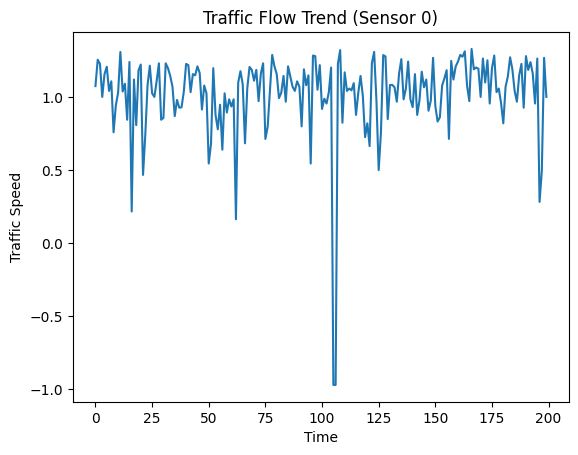

In [9]:
# Traffic Trend
plt.figure()
plt.plot(X[:200, -1, 0, 0])
plt.title("Traffic Flow Trend (Sensor 0)")
plt.xlabel("Time")
plt.ylabel("Traffic Speed")
plt.show()

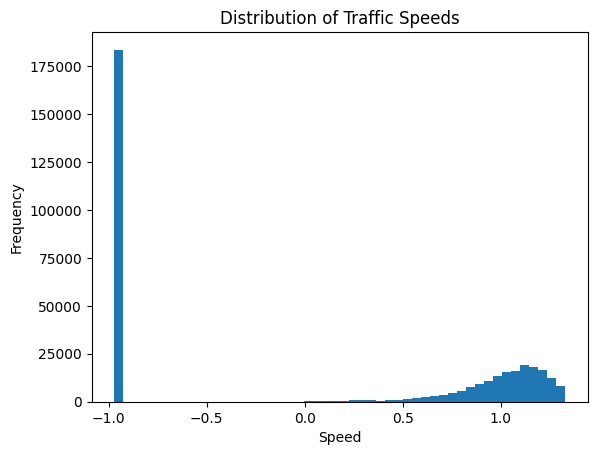

In [10]:
#Distribution of Speeds
plt.figure()
plt.hist(X.flatten(), bins=50)
plt.title("Distribution of Traffic Speeds")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

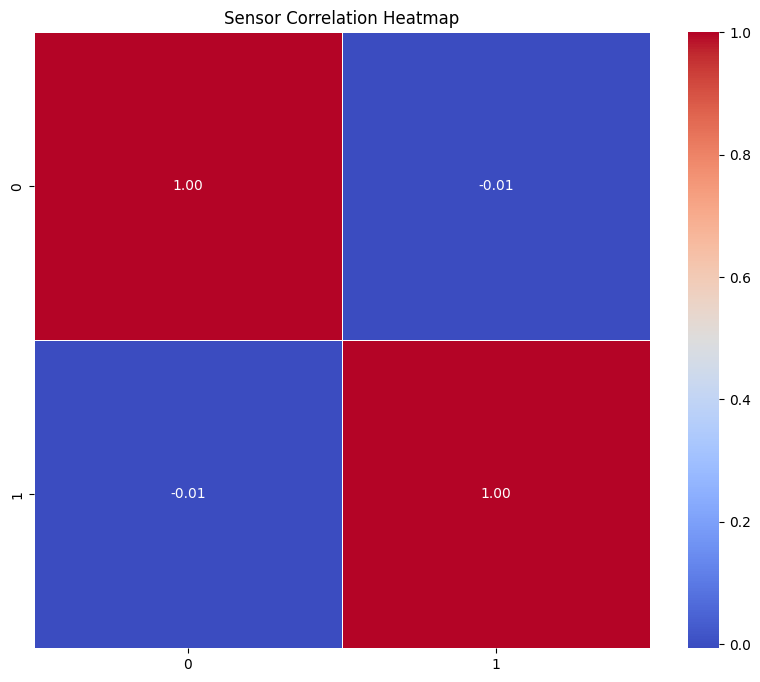

In [11]:
#Correlation Heatmap
import seaborn as sns

corr = np.corrcoef(X[:, -1, :20, 0].T)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Sensor Correlation Heatmap")
plt.show()

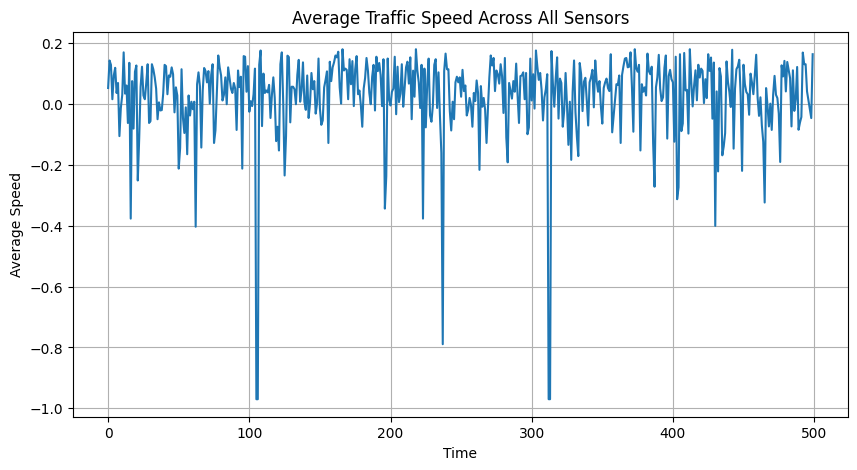

In [12]:
# Average traffic across all sensors
avg_traffic = X[:, -1, :, 0].mean(axis=1)

plt.figure(figsize=(10,5))
plt.plot(avg_traffic[:500])
plt.title("Average Traffic Speed Across All Sensors")
plt.xlabel("Time")
plt.ylabel("Average Speed")
plt.grid(True)
plt.show()

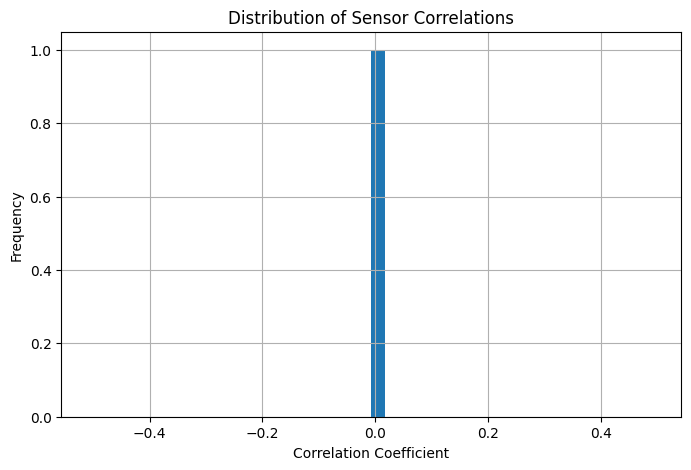

In [13]:
corr_matrix = np.corrcoef(X[:, -1, :, 0].T)
corr_values = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]

plt.figure(figsize=(8,5))
plt.hist(corr_values, bins=40)
plt.title("Distribution of Sensor Correlations")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [14]:
# Building adjacency (robust version)

node_series = X[:, -1, :, 0].T
corr_matrix = np.corrcoef(node_series)
corr_matrix = np.nan_to_num(corr_matrix)

# Lower threshold
threshold = 0.1

adj_matrix = np.where(np.abs(corr_matrix) > threshold, 1, 0)
np.fill_diagonal(adj_matrix, 0)

# fallbacking to k-nearest neighbors
if adj_matrix.sum() == 0:
    print("Correlation graph empty. Switching to KNN graph...")
    k = 5
    adj_matrix = np.zeros_like(corr_matrix)

    for i in range(corr_matrix.shape[0]):
        idx = np.argsort(-np.abs(corr_matrix[i]))[1:k+1]
        adj_matrix[i, idx] = 1

adj = torch.tensor(adj_matrix, dtype=torch.float32)
edge_index, edge_weight = dense_to_sparse(adj)
edge_index = edge_index.to(device)

print("Final Number of edges:", edge_index.shape[1])

Correlation graph empty. Switching to KNN graph...
Final Number of edges: 2


In [15]:
#Train - test - split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=64
)

In [16]:
#LSTM MODEL
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(NUM_NODES, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, OUTPUT_STEPS * NUM_NODES)

    def forward(self, x):
        x = x.squeeze(-1)
        out,_ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.view(-1, OUTPUT_STEPS, NUM_NODES)

In [17]:
#GRU MODEL
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()

        # GRU layer
        self.gru = nn.GRU(
            input_size=NUM_NODES,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        # connected layer
        self.fc = nn.Linear(64, OUTPUT_STEPS * NUM_NODES)

    def forward(self, x):


        x = x.squeeze(-1)

        out, _ = self.gru(x)


        out = out[:, -1, :]

        out = self.fc(out)


        return out.view(-1, OUTPUT_STEPS, NUM_NODES)

In [18]:
#GCN MODEL
class StrongGCN(nn.Module):
    def __init__(self):
        super().__init__()

        # Temporal encoding per node
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        # Spatial graph layers
        self.gcn1 = GCNConv(64, 64)
        self.gcn2 = GCNConv(64, 64)

        # Final prediction
        self.fc = nn.Linear(64, OUTPUT_STEPS)

    def forward(self, x):
        # x shape: batch, time, nodes, 1

        B, T, N, C = x.shape

        # Processing each node
        x = x.permute(0,2,1,3)
        x = x.reshape(B*N, T, 1)

        h,_ = self.gru(x)
        h = h[:, -1, :]

        h = h.reshape(B, N, 64)

        outputs = []

        for batch in h:

            node_feat = F.relu(self.gcn1(batch, edge_index))
            node_feat = F.relu(self.gcn2(node_feat, edge_index))

            out = self.fc(node_feat)
            outputs.append(out.T)

        return torch.stack(outputs)

In [19]:
# STGCN MODEL
class STGCNBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.temp1 = nn.Conv2d(in_channels, hidden_channels,
                               kernel_size=(3,1), padding=(1,0))
        self.gcn = GCNConv(hidden_channels, hidden_channels)
        self.temp2 = nn.Conv2d(hidden_channels, hidden_channels,
                               kernel_size=(3,1), padding=(1,0))

    def forward(self, x):
        x = self.temp1(x)
        B, C, T, N = x.shape

        x = x.permute(0,2,3,1).reshape(B*T, N, C)

        x = self.gcn(
            x.reshape(-1, C),
            edge_index
        )

        x = x.reshape(B*T, N, C)
        x = x.reshape(B, T, N, C).permute(0,3,1,2)

        return self.temp2(x)

In [20]:
class STGCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = STGCNBlock(1, 16)
        self.block2 = STGCNBlock(16, 16)
        self.final = nn.Conv2d(16, OUTPUT_STEPS, kernel_size=(1,1))

    def forward(self, x):
        x = x.permute(0,3,1,2)
        x = self.block1(x)
        x = self.block2(x)
        x = self.final(x)
        return x.mean(dim=2)

In [21]:
#Training
def train_model(model, epochs=8):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb,yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

    return model

In [22]:
#Evaluating
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import math

def evaluate_model(model):

    model.eval()
    preds = []
    actuals = []

    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb)
            preds.append(out.cpu().numpy())
            actuals.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    actuals = np.concatenate(actuals)

    # inverse scaling
    preds = scaler.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
    actuals = scaler.inverse_transform(actuals.reshape(-1,1)).reshape(actuals.shape)

    mae = mean_absolute_error(actuals.flatten(), preds.flatten())
    rmse = math.sqrt(mean_squared_error(actuals.flatten(), preds.flatten()))
    r2 = r2_score(actuals.flatten(), preds.flatten())

    # MAPE
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

    print("MAE:", round(mae,4))
    print("RMSE:", round(rmse,4))
    print("MAPE:", round(mape,4))
    print("R2 Score:", round(r2,4))

    return mae, rmse, mape, r2

In [23]:
#Results
results = []

print("\nTraining LSTM")
lstm = train_model(LSTMModel())
results.append(["LSTM", *evaluate_model(lstm)])


Training LSTM
Epoch 1/8, Loss: 0.1229
Epoch 2/8, Loss: 0.0318
Epoch 3/8, Loss: 0.0280
Epoch 4/8, Loss: 0.0276
Epoch 5/8, Loss: 0.0273
Epoch 6/8, Loss: 0.0271
Epoch 7/8, Loss: 0.0270
Epoch 8/8, Loss: 0.0269
MAE: 4.0304
RMSE: 10.0417
MAPE: 31050014.0
R2 Score: 0.8875


In [24]:
#Results
print("\nTraining GRU")
gru = train_model(GRUModel())
results.append(["GRU", *evaluate_model(gru)])


Training GRU
Epoch 1/8, Loss: 0.0902
Epoch 2/8, Loss: 0.0295
Epoch 3/8, Loss: 0.0272
Epoch 4/8, Loss: 0.0268
Epoch 5/8, Loss: 0.0268
Epoch 6/8, Loss: 0.0267
Epoch 7/8, Loss: 0.0265
Epoch 8/8, Loss: 0.0266
MAE: 3.8765
RMSE: 10.0342
MAPE: 31476496.0
R2 Score: 0.8877


In [25]:
#Results
print("\nTraining Strong GCN")
gcn = train_model(StrongGCN(), epochs=12)
results.append(["GCN", *evaluate_model(gcn)])


Training Strong GCN
Epoch 1/12, Loss: 0.9866
Epoch 2/12, Loss: 0.9845
Epoch 3/12, Loss: 0.9840
Epoch 4/12, Loss: 0.9841
Epoch 5/12, Loss: 0.9840
Epoch 6/12, Loss: 0.9838
Epoch 7/12, Loss: 0.9838
Epoch 8/12, Loss: 0.9837
Epoch 9/12, Loss: 0.9836
Epoch 10/12, Loss: 0.9838
Epoch 11/12, Loss: 0.9836
Epoch 12/12, Loss: 0.9835
MAE: 28.6043
RMSE: 29.63
MAPE: 16174447.0
R2 Score: 0.0209


In [26]:
#Results
print("\nTraining STGCN")
stgcn = train_model(STGCN())
results.append(["STGCN", *evaluate_model(stgcn)])


Training STGCN
Epoch 1/8, Loss: 0.0969
Epoch 2/8, Loss: 0.0347
Epoch 3/8, Loss: 0.0344
Epoch 4/8, Loss: 0.0340
Epoch 5/8, Loss: 0.0337
Epoch 6/8, Loss: 0.0333
Epoch 7/8, Loss: 0.0332
Epoch 8/8, Loss: 0.0329
MAE: 4.7633
RMSE: 10.5129
MAPE: 29444798.0
R2 Score: 0.8767


In [27]:
#Comparision table
comparison_df = pd.DataFrame(results,
                             columns=["Model","MAE","RMSE","MAPE","R2"])
print(comparison_df)

   Model        MAE       RMSE        MAPE        R2
0   LSTM   4.030449  10.041673  31050012.0  0.887541
1    GRU   3.876514  10.034202  31476494.0  0.887708
2    GCN  28.604315  29.629995  16174447.0  0.020856
3  STGCN   4.763312  10.512942  29444796.0  0.876737


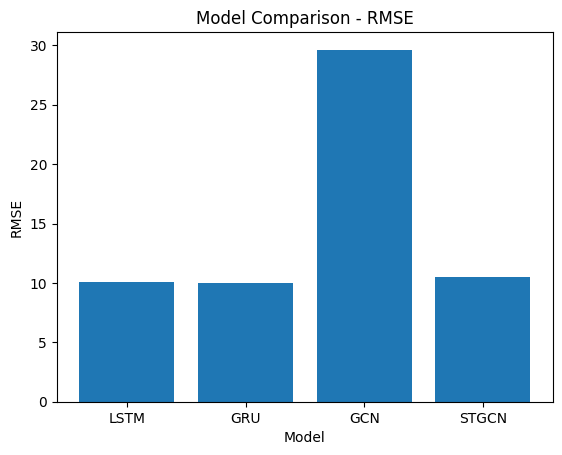

In [28]:
# RMSE comparison
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

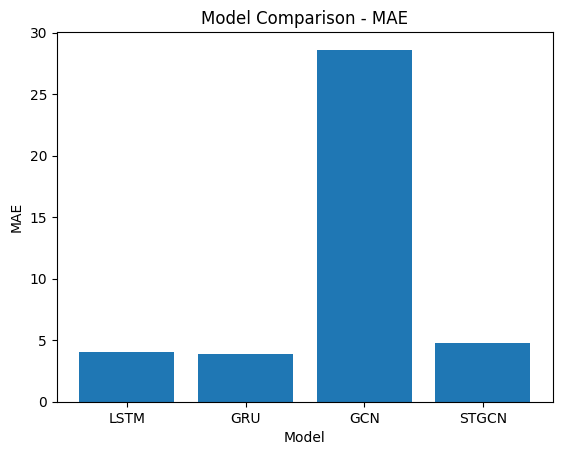

In [29]:
# MAE comparison
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["MAE"])
plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

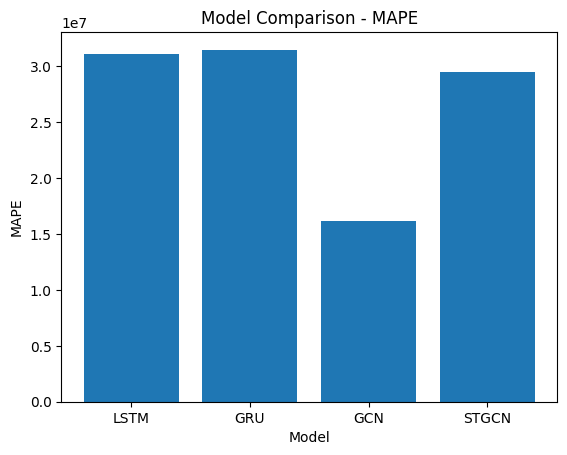

In [30]:
# MAPE comparison
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["MAPE"])
plt.title("Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE")
plt.show()

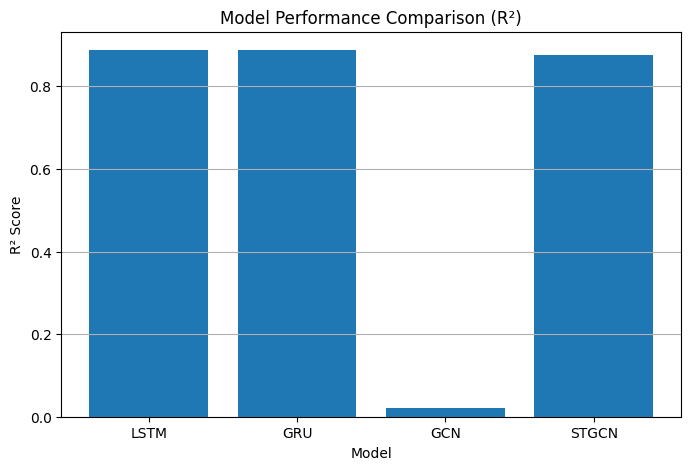

In [31]:
#Comparision
plt.figure(figsize=(8,5))

models = comparison_df["Model"]
scores = comparison_df["R2"]

plt.bar(models, scores)

plt.title("Model Performance Comparison (R²)")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.grid(axis="y")

plt.show()

In [32]:
def plot_predictions(model):

    model.eval()

    with torch.no_grad():
        xb, yb = next(iter(test_loader))
        preds = model(xb).cpu().numpy()
        actual = yb.cpu().numpy()

    preds = scaler.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
    actual = scaler.inverse_transform(actual.reshape(-1,1)).reshape(actual.shape)

    plt.figure(figsize=(10,5))

    plt.plot(actual[0,:,0], label="Actual")
    plt.plot(preds[0,:,0], label="Predicted")

    plt.title("Prediction vs Actual Traffic Speed")
    plt.xlabel("Future Time Step")
    plt.ylabel("Speed")

    plt.legend()
    plt.grid(True)

    plt.show()

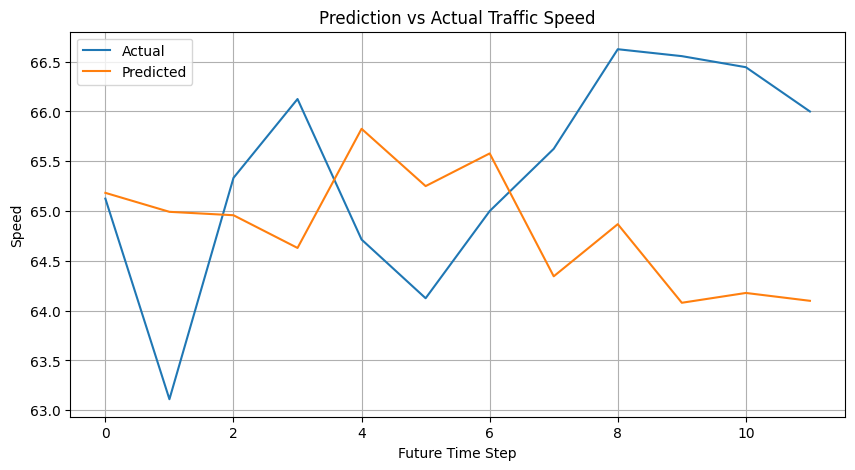

In [33]:
#Prediction Vs Actual for GRU
plot_predictions(gru)

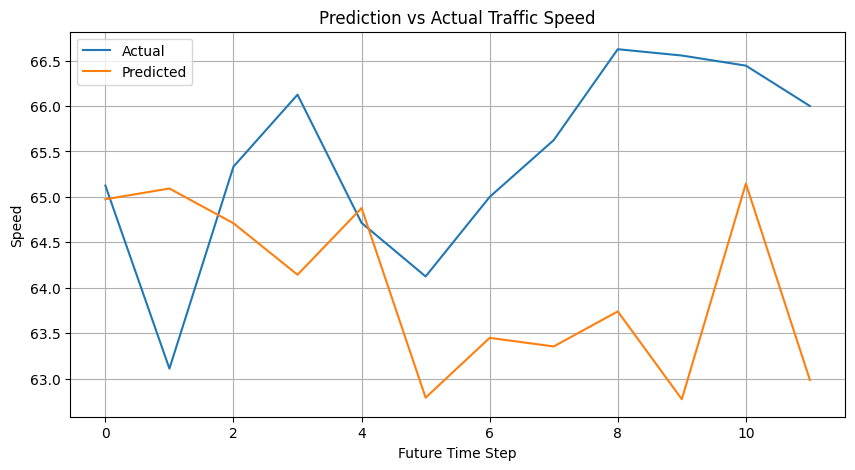

In [34]:
#Prediction Vs Actual for STGCN
plot_predictions(stgcn)

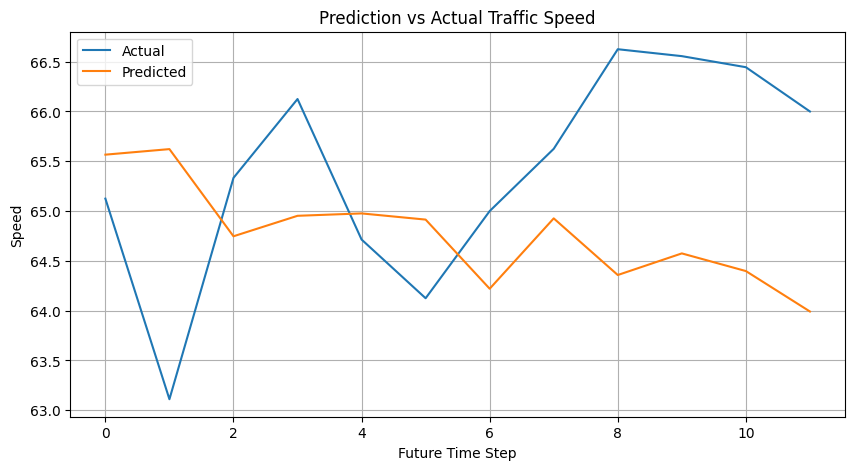

In [35]:
#Prediction Vs Actual for LSTM
plot_predictions(lstm)

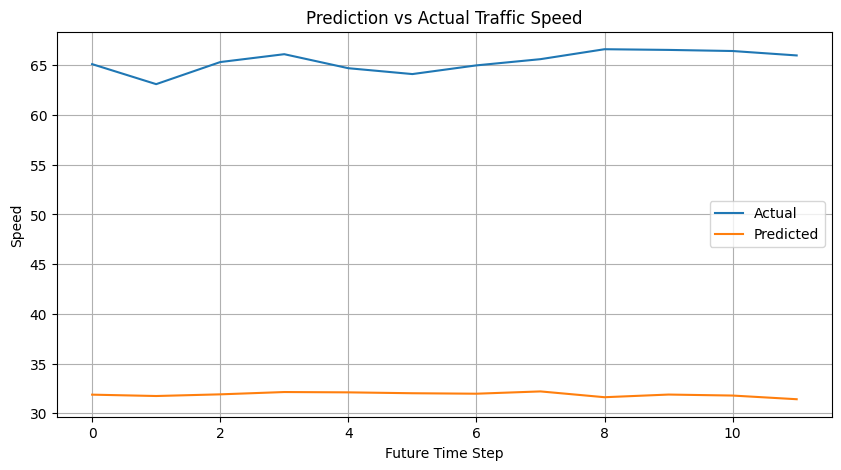

In [36]:
#Prediction Vs Actual for GCN
plot_predictions(gcn)

In [37]:
#Saving the model
torch.save(gru.state_dict(), "Gru_model.pth")

In [38]:
#Loading new data
df_new = ds["test"].to_pandas().head(3000)

In [39]:
#Preprocessing
X_new = df_new[x_cols].values.reshape(-1, INPUT_STEPS, NUM_NODES, 1)
y_new = df_new[y_cols].values.reshape(-1, OUTPUT_STEPS, NUM_NODES)

X_new = scaler.transform(X_new.reshape(-1,1)).reshape(X_new.shape)
y_new = scaler.transform(y_new.reshape(-1,1)).reshape(y_new.shape)

X_new = torch.tensor(X_new, dtype=torch.float32).to(device)
y_new = torch.tensor(y_new, dtype=torch.float32).to(device)

In [40]:
#Evaluating
def safe_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100

model = GRUModel()
model.load_state_dict(torch.load("Gru_model.pth"))
model.to(device)
model.eval()

with torch.no_grad():
    preds = model(X_new).cpu().numpy()
    actuals = y_new.cpu().numpy()

preds = scaler.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
actuals = scaler.inverse_transform(actuals.reshape(-1,1)).reshape(actuals.shape)

mae = mean_absolute_error(actuals.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actuals.flatten(), preds.flatten()))
r2 = r2_score(actuals.flatten(), preds.flatten())
mape = safe_mape(actuals, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2:", r2)

MAE: 1.4525725841522217
RMSE: 3.205888997774603
MAPE: 548649.9
R2: 0.9893758893013


In [41]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [42]:
df_new.to_csv("test_input.csv", index=False)